In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


sns.set(rc={"figure.figsize":(12,10)})

In [210]:
df=pd.read_csv("titanic_data.csv")

In [211]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Types of Feature

### Categorical-Sex and Embarked
### Conti-Age,Fare
### Discrete-SibSp,Parch
### Alphanumeric-Cabin

In [213]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [214]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Numerical Data Analysis

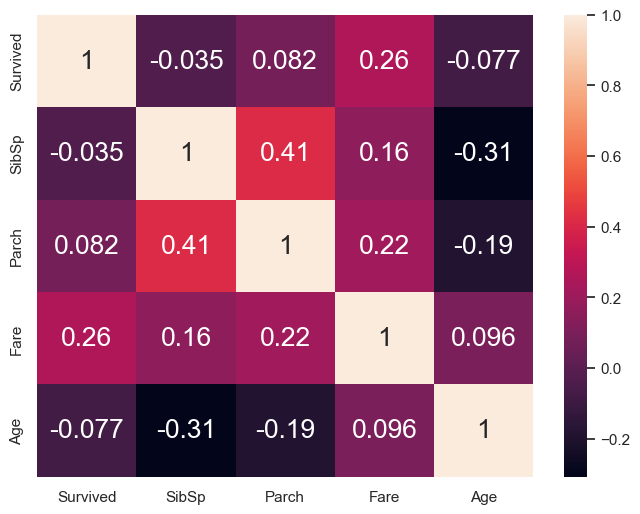

In [216]:
plt.figure(figsize=(8,6))
heaatmap=sns.heatmap(df[["Survived","SibSp","Parch","Fare","Age"]].corr(),annot=True,annot_kws={"size": 19})

### sibsp-num of siblings or spouses aboard the titanic

In [218]:
df["SibSp"].nunique()

7

In [219]:
df["SibSp"].unique()

array([1, 0, 3, 4, 2, 5, 8], dtype=int64)

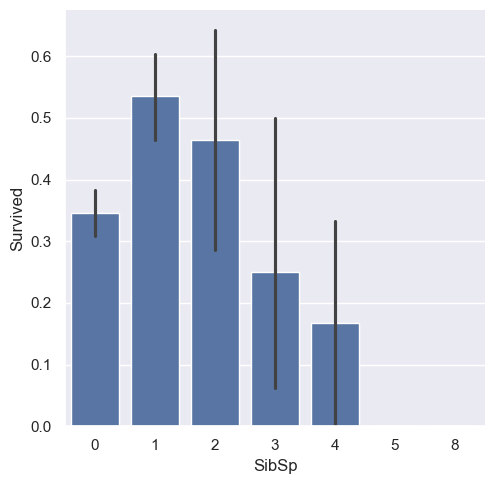

In [220]:
sns.catplot(x="SibSp",y="Survived",data=df,kind="bar")

## Age

C:\Users\Asus\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
C:\Users\Asus\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


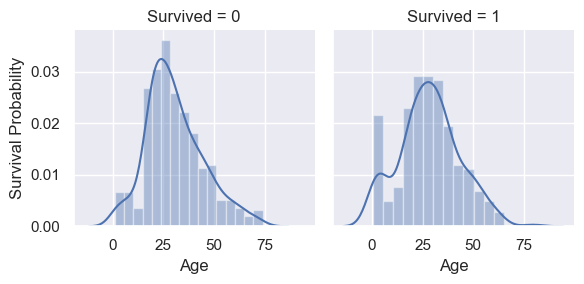

In [222]:
age_visual=sns.FacetGrid(df,col="Survived")
age_visual=age_visual.map(sns.distplot,"Age").set_ylabels("Survival Probability")

## Sex

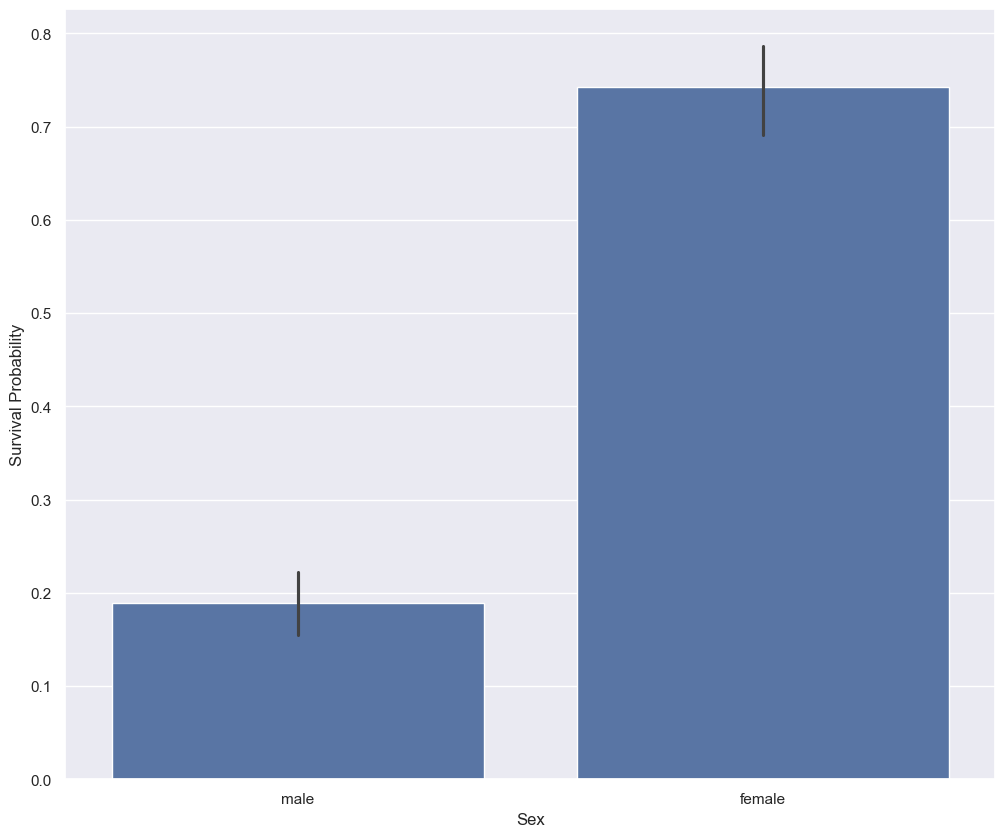

In [224]:
age_plot=sns.barplot(x="Sex",y="Survived",data=df).set_ylabel("Survival Probability")

In [225]:
df[["Sex","Survived"]].groupby("Sex").mean()

,Survived
Sex,
female,0.742038
male,0.188908


## PClass

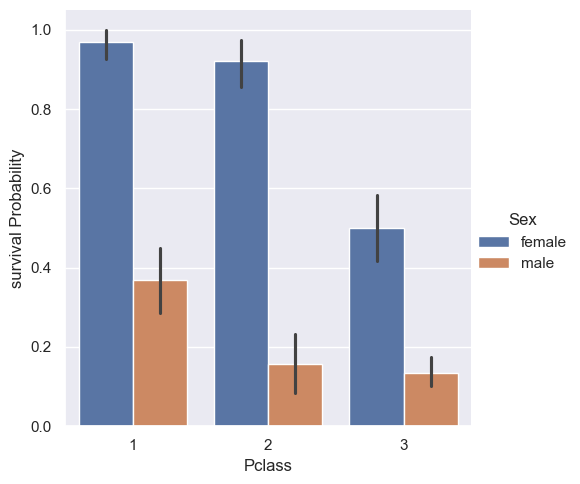

In [227]:
pclass=sns.catplot(x="Pclass",y="Survived",data=df,kind="bar",hue="Sex")
pclass=pclass.set_ylabels("survival Probability")

### Embarked

In [229]:
df["Embarked"].isnull().sum()

2

In [230]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [231]:
df["Embarked"]=df["Embarked"].fillna("S")

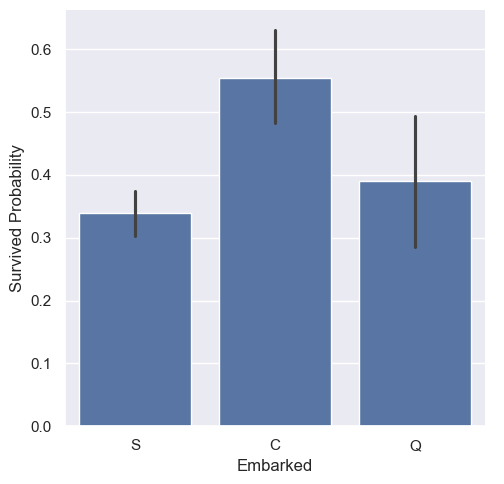

In [232]:
q=sns.catplot(x="Embarked",y="Survived",data=df,kind="bar")
q=q.set_ylabels("Survived Probability")

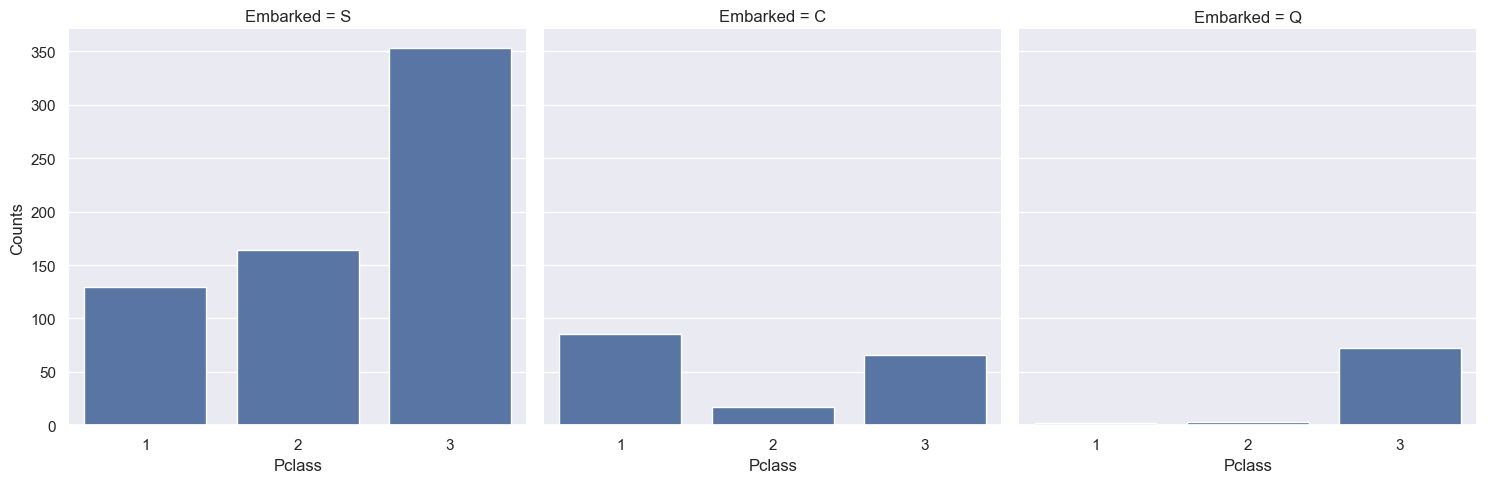

In [233]:
g=sns.catplot(x="Pclass",col="Embarked",data=df,kind="count")
g.despine(left=True)
g=g.set_ylabels("Counts")

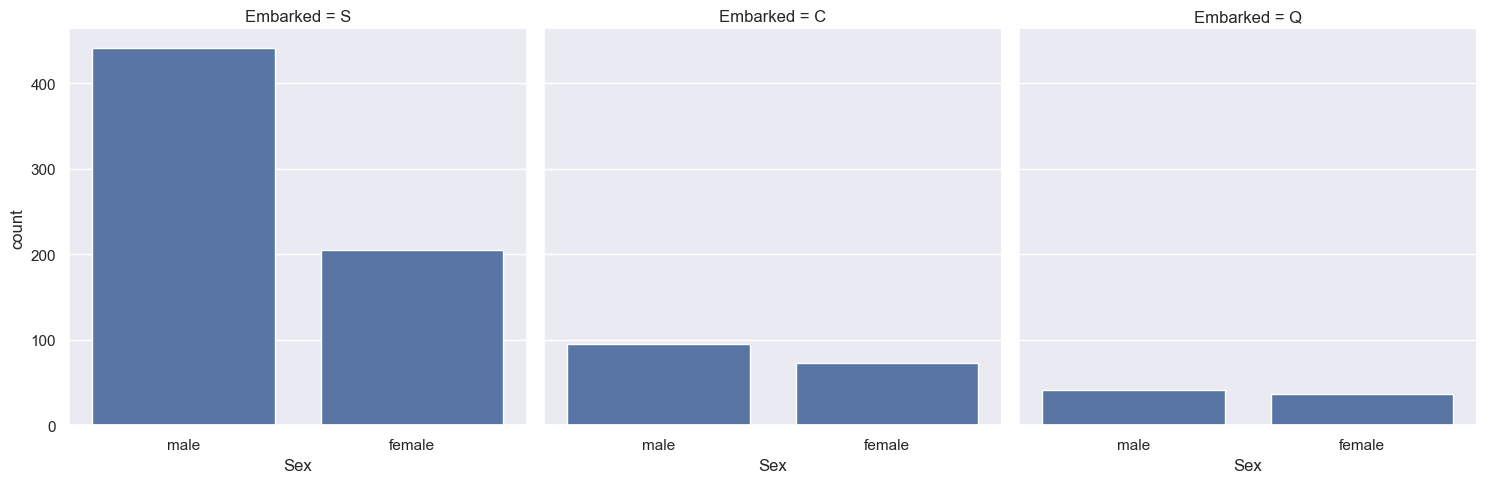

In [234]:
q=sns.catplot(x="Sex",col="Embarked",data=df,kind="count")

## Preparing Data

In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [237]:
mean=df["Age"].mean()
std=df["Age"].std()

is_null=df["Age"].isnull().sum()

In [238]:
print(mean,std,is_null)

29.69911764705882 14.526497332334044 177


In [239]:
rand_age=np.random.randint(mean-std,mean+std,size=is_null)

In [240]:
rand_age

array([33, 25, 33, 26, 38, 39, 34, 37, 25, 34, 21, 25, 40, 17, 39, 26, 42,
       43, 18, 41, 35, 42, 23, 15, 43, 17, 40, 20, 18, 42, 34, 40, 37, 30,
       39, 33, 34, 40, 19, 19, 22, 16, 16, 30, 37, 27, 33, 43, 33, 33, 43,
       22, 34, 17, 22, 30, 22, 42, 35, 32, 16, 37, 36, 17, 21, 42, 39, 19,
       40, 19, 43, 40, 28, 26, 43, 21, 24, 18, 40, 28, 33, 26, 30, 23, 42,
       29, 34, 29, 29, 19, 32, 17, 34, 23, 31, 33, 31, 23, 42, 15, 27, 22,
       17, 23, 34, 19, 23, 32, 30, 25, 28, 29, 15, 42, 41, 23, 23, 22, 19,
       26, 34, 27, 22, 22, 37, 20, 39, 30, 33, 24, 22, 33, 19, 30, 30, 38,
       37, 33, 18, 31, 38, 21, 27, 40, 36, 17, 39, 15, 25, 43, 42, 16, 40,
       16, 35, 42, 20, 18, 23, 42, 43, 39, 28, 27, 32, 36, 17, 42, 31, 20,
       34, 26, 32, 23, 43, 19, 24])

In [241]:
a=df["Age"].copy()
a[np.isnan(a)]=rand_age
df["Age"]=a

In [242]:
df.drop(["PassengerId","Cabin","Ticket","Name"],axis=1,inplace=True)

In [243]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [244]:
genders={"male":0,"female":1}
df["Sex"]=df["Sex"].map(genders)

In [245]:
ports={"S":0,"C":1,"Q":2}
df["Embarked"]=df["Embarked"].map(ports)

In [246]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


## Splitting the data

In [248]:
x=df.drop("Survived",axis=1)
y=df["Survived"]

In [301]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

## Scaling

In [304]:
from sklearn.preprocessing import StandardScaler 
sc_x=StandardScaler()
xtrain=sc_x.fit_transform(x_train)
xtest=sc_x.fit_transform(x_test)

## Classification

In [307]:
logreg=LogisticRegression()
svc_cls=SVC()
dt_cls=DecisionTreeClassifier()
knn_cls=KNeighborsClassifier()
rf_cls=RandomForestClassifier(n_estimators=1000)

In [309]:
logreg.fit(xtrain,y_train)
svc_cls.fit(xtrain,y_train)
dt_cls.fit(xtrain,y_train)
knn_cls.fit(xtrain,y_train)
rf_cls.fit(xtrain,y_train)

RandomForestClassifier(n_estimators=1000)

In [311]:
logreg_ypred=logreg.predict(xtest)
svc_cls_ypred=svc_cls.predict(xtest)
dt_cls_ypred=dt_cls.predict(xtest)
knn_cls_ypred=knn_cls.predict(xtest)
rf_cls_ypred=rf_cls.predict(xtest)

# Accuracy

In [314]:
from sklearn.metrics import accuracy_score

logreg_acc=accuracy_score(y_test,logreg_ypred)
svc_acc=accuracy_score(y_test,svc_cls_ypred)
dt_acc=accuracy_score(y_test,dt_cls_ypred)
knn_acc=accuracy_score(y_test,knn_cls_ypred)
rf_acc=accuracy_score(y_test,rf_cls_ypred)

In [316]:
print("logreg_acc: ",round(logreg_acc*100,2))
print("svc_acc: ",round(svc_acc*100,2))
print("dt_acc: ",round(dt_acc*100,2))
print("knn_acc: ",round(knn_acc*100,2))
print("rf_acc: ",round(rf_acc*100,2))

logreg_acc:  80.97
svc_acc:  82.09
dt_acc:  78.73
knn_acc:  80.97
rf_acc:  79.85
